In [1]:
#Import das bibliotecas que serão usadas. Como no último EP, a biblioteca NUMBA será utilizada para 
#transformar a função principal (que usa o algoritmo de Verlet) em linguagem compilada, acelerando sua execução
import matplotlib.pyplot as plt
from Funcs import *
from numba import njit
import numpy as np

G = 1#4*np.pi**2

In [2]:
# --- TESTANDO O CÓDIGO ---
# Vamos testar com o sistema Terra-Lua (mu = 0.01215)
mu = 0.03
pontos_colineares = newton_raphson_lagrange(mu)

print(f"Posições no eixo X para mu = {mu}:")
print(f"L1: x = {pontos_colineares[0]:.8f}")
print(f"L2: x = {pontos_colineares[1]:.8f}")
print(f"L3: x = {pontos_colineares[2]:.8f}")

x = 1/2 - mu
y = -np.sqrt(3)/2

jac_mat = Jac(x, y, mu)

vals, _ = np.linalg.eig(jac_mat)


Posições no eixo X para mu = 0.03:
L1: x = 0.76964349
L2: x = 1.20119125
L3: x = -1.01249851


In [3]:
xs = np.arange(-1.5, 1.5, 0.01)
ys = np.arange(-1.5, 1.5, 0.01)

Us = np.zeros((len(xs), len(ys)))

for i in range(len(xs)):
    for j in range(len(ys)):
        Us[i, j] = 0.5*(xs[i]**2 + ys[j]**2) + (1-mu)/(((mu+xs[i])**2 + ys[j]**2)**(0.5)) + mu/(((1-mu-xs[i])**2 + ys[j]**2)**(0.5))

Ugrads = np.gradient(Us, 0.01)

[ 0.76964349  1.20119125 -1.01249851]


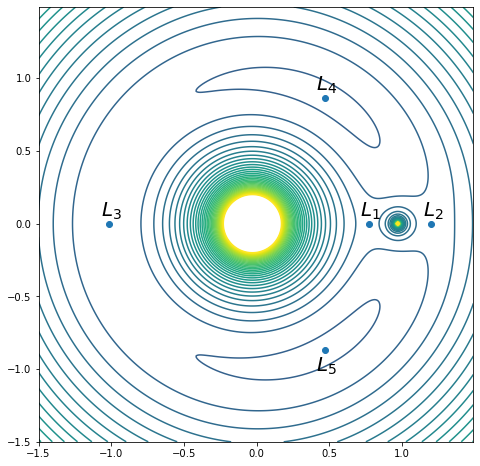

In [4]:
plt.figure(figsize = (12, 8))

print(pontos_colineares)
plt.contour(xs, ys, Us.T, levels = np.arange(0, 5, 0.1))
plt.scatter([pontos_colineares[0], pontos_colineares[1], pontos_colineares[2], 1/2-mu, 1/2-mu], [0., 0., 0., np.sqrt(3)/2, -np.sqrt(3)/2])
plt.text(pontos_colineares[0]-6e-2, 0.05, s = r'$L_1$', fontsize = 20)
plt.text(pontos_colineares[1]-6e-2, 0.05, s = r'$L_2$', fontsize = 20)
plt.text(pontos_colineares[2]-6e-2, 0.05, s = r'$L_3$', fontsize = 20)
plt.text(1/2-mu-6e-2, np.sqrt(3)/2 + 0.05, s = r'$L_4$', fontsize = 20)
plt.text(1/2-mu-6e-2, -np.sqrt(3)/2 - 0.15, s = r'$L_5$', fontsize = 20)
plt.gca().set_aspect('equal')
#plt.pcolormesh(xs, ys, Us)
#plt.colorbar()

In [8]:
N = 50

T = 200
h = 1e-3

m_arr = np.array([1, 1e-3])
mu = m_arr[1]/(m_arr[0] + m_arr[1])


L1_pos = np.array([pontos_colineares[0], 0])
L2_pos = np.array([pontos_colineares[1], 0])
L3_pos = np.array([pontos_colineares[2], 0])
L4_pos = np.array([1/2-mu, np.sqrt(3)/2])
L5_pos = np.array([1/2-mu, -np.sqrt(3)/2])

r0 = np.zeros((N, 2))
v0 = np.zeros((N, 2))

prob_amp = 1e-3

np.random.seed(42)
r0[0:int(N/5)] = L1_pos + prob_amp*np.random.randn(int(N/5), 2)
np.random.seed(42)
r0[int(N/5):int(2*N/5), :] = L2_pos + prob_amp*np.random.randn(int(N/5), 2)
np.random.seed(42)
r0[int(2*N/5):int(3*N/5), :] = L3_pos + prob_amp*np.random.randn(int(N/5), 2)
np.random.seed(42)
r0[int(3*N/5):int(4*N/5), :] = L4_pos + prob_amp*np.random.randn(int(N/5), 2)
np.random.seed(42)
r0[int(4*N/5):N, :] = L5_pos + prob_amp*np.random.randn(int(N/5), 2)

r1, v1 = RK4_Rotating(N, mu, r0, v0, T, h)

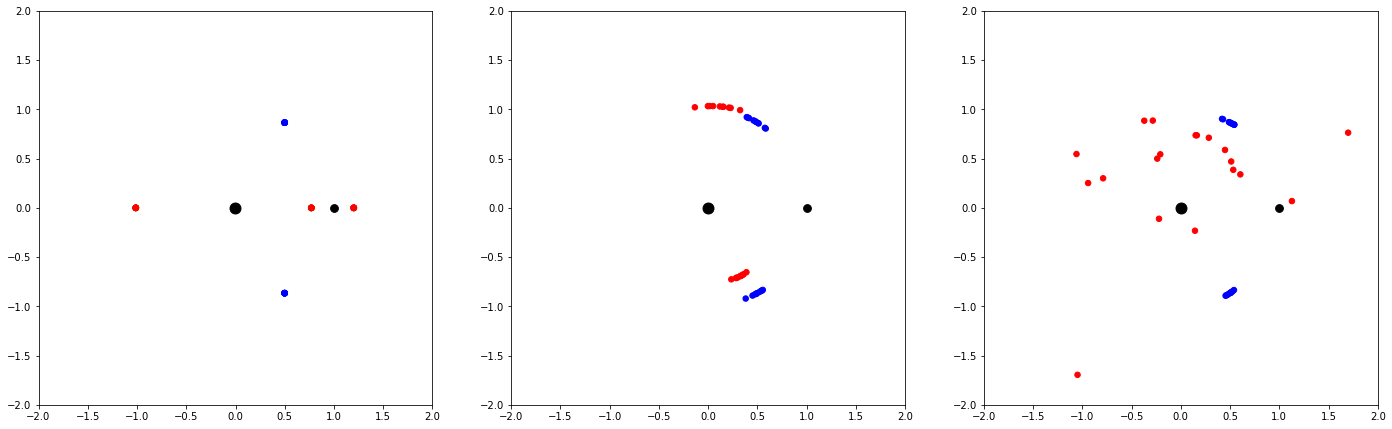

In [9]:
cores = ['red'] * int(6*N/10) + ['blue'] * int(4*N/10)

fig, ax = plt.subplots(1, 3, figsize = (24, 8))

ax[0].scatter(r1[0, :, 0], r1[0, :, 1], c=cores, s=30)

ax[0].scatter(-mu, 0., s = 120, c = 'black')
ax[0].scatter(1-mu, 0., s = 60, c = 'black')
ax[0].set_aspect('equal')
#scat = ax.scatter(x_inicial, y_inicial, c='purple', alpha=0.7)

# É muito importante fixar os limites dos eixos com base em TODOS os dados.
# Isso impede que o gráfico fique mudando de escala durante a animação.
ax[0].set_xlim(-2, 2)
ax[0].set_ylim(-2, 2)


ax[1].scatter(r1[int(len(r1)/10), :, 0], r1[int(len(r1)/10), :, 1], c=cores, s=30)

ax[1].scatter(-mu, 0., s = 120, c = 'black')
ax[1].scatter(1-mu, 0., s = 60, c = 'black')
ax[1].set_aspect('equal')
#scat = ax.scatter(x_inicial, y_inicial, c='purple', alpha=0.7)

# É muito importante fixar os limites dos eixos com base em TODOS os dados.
# Isso impede que o gráfico fique mudando de escala durante a animação.
ax[1].set_xlim(-2, 2)
ax[1].set_ylim(-2, 2)


ax[2].scatter(r1[-1, :, 0], r1[-1, :, 1], c=cores, s=30)

ax[2].scatter(-mu, 0., s = 120, c = 'black')
ax[2].scatter(1-mu, 0., s = 60, c = 'black')
ax[2].set_aspect('equal')
#scat = ax.scatter(x_inicial, y_inicial, c='purple', alpha=0.7)

# É muito importante fixar os limites dos eixos com base em TODOS os dados.
# Isso impede que o gráfico fique mudando de escala durante a animação.
ax[2].set_xlim(-2, 2)
ax[2].set_ylim(-2, 2)

plt.savefig('Orbital_prints.pdf', format = 'pdf')

In [10]:
anim = Animate(N, h, mu, 1e-1, r1)


Animation size has reached 20977483 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


In [79]:
mu_arr = np.arange(1e-3, 1, 1e-3)

eig_vals = np.zeros((3, len(mu_arr), 4), dtype = complex)
for i in range(len(mu_arr)):
    pontos_col = newton_raphson_lagrange(mu_arr[i])
    for j in range(3):
        jac_mat = Jac(pontos_col[j], 0., mu_arr[i])

        vals = np.linalg.eigvals(jac_mat)
        eig_vals[j, i] = vals

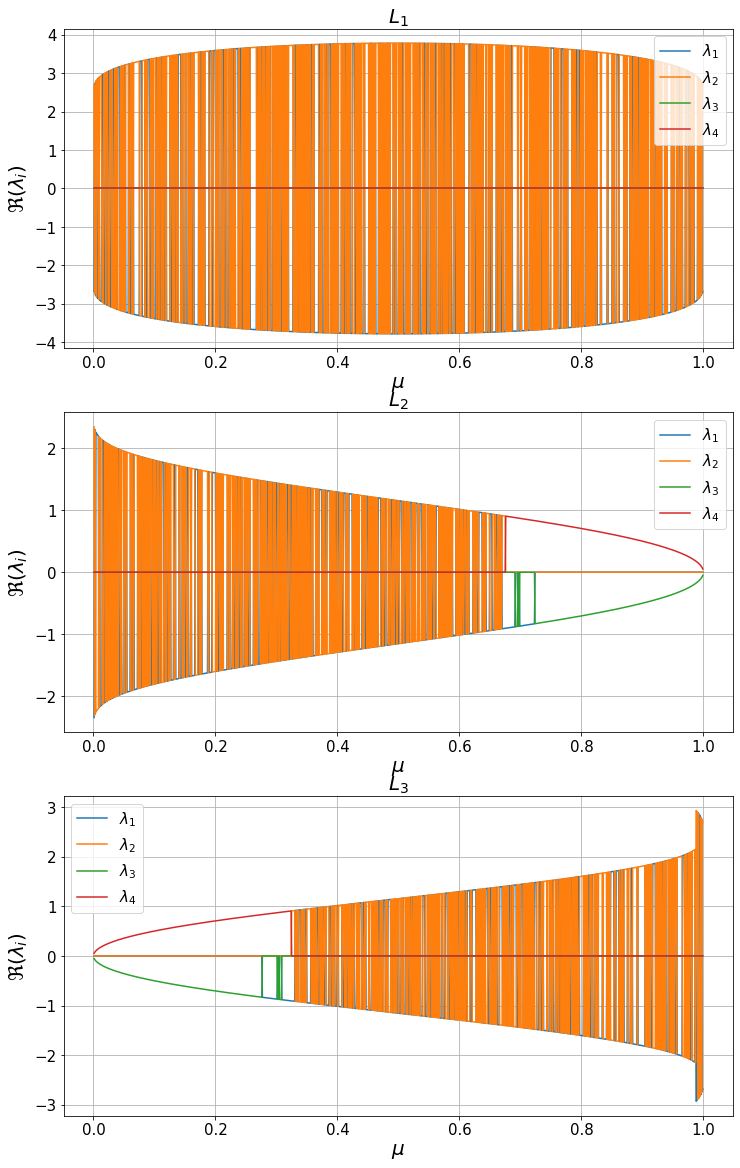

In [80]:
fig, ax = plt.subplots(3, figsize = (12, 20))

for j in range(3):
    for i in range(4):
        ax[j].set_title(fr'$L_{1+j}$', fontsize = 20)
        ax[j].plot(mu_arr, np.real(eig_vals[j, :, i]), label = fr'$\lambda_{1+i}$')
        ax[j].set_xlabel(r'$\mu$', fontsize = 20)
        ax[j].set_ylabel(r'$\Re(\lambda_i)$', fontsize = 20)
        ax[j].tick_params(labelsize = 15)

        ax[j].legend(fontsize = 15)
        ax[j].grid(visible = True)

plt.savefig('colinear_eigvals.pdf', format = 'pdf')

In [81]:
eig_vals = np.zeros((2, len(mu_arr), 4), dtype = complex)
for i in range(len(mu_arr)):
    pontos_col = newton_raphson_lagrange(mu_arr[i])
    diag_points = np.array([[0.5-mu_arr[i], np.sqrt(3)/2], [0.5-mu_arr[i], -np.sqrt(3)/2]])
    for j in range(2):
        jac_mat = Jac(diag_points[j, 0], diag_points[j, 1], mu_arr[i])

        vals = np.linalg.eigvals(jac_mat)
        eig_vals[j, i] = vals

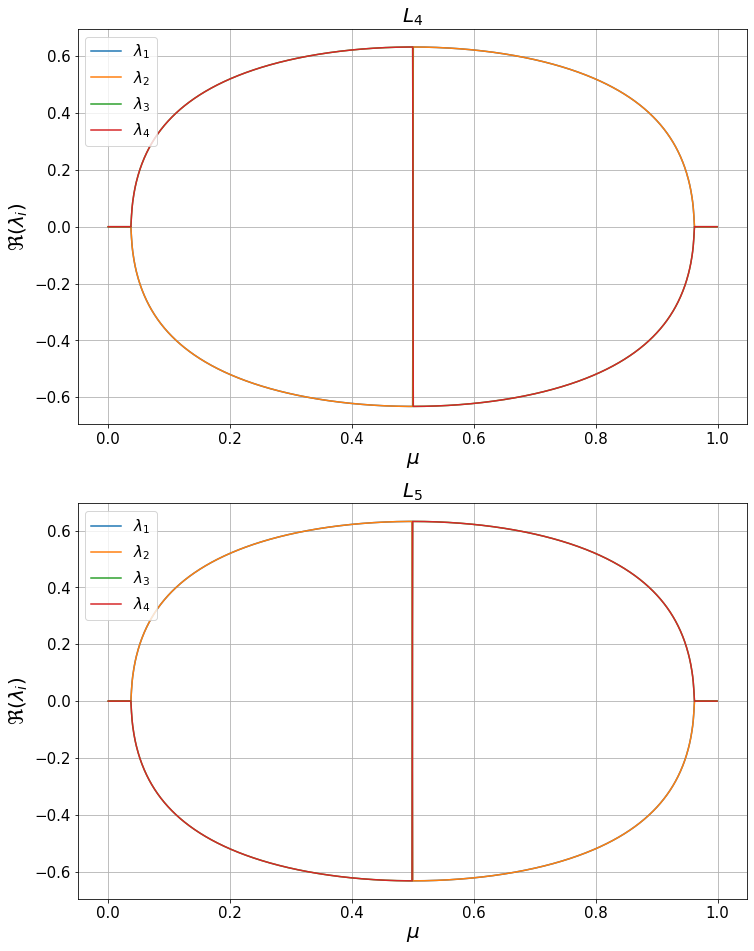

In [82]:
fig, ax = plt.subplots(2, figsize = (12, 16))

for j in range(2):
    for i in range(4):
        ax[j].set_title(fr'$L_{4+j}$', fontsize = 20)
        ax[j].plot(mu_arr, np.real(eig_vals[j, :, i]), label = fr'$\lambda_{1+i}$')
        ax[j].set_xlabel(r'$\mu$', fontsize = 20)
        ax[j].set_ylabel(r'$\Re(\lambda_i)$', fontsize = 20)
        ax[j].tick_params(labelsize = 15)

        ax[j].legend(loc = 'upper left', fontsize = 15)
        ax[j].grid(visible = True)

plt.savefig('triang_eigvals.pdf', format = 'pdf')

In [181]:
N = 1

T = 160
h = 1e-4

mu = 1e-3

L1_pos = np.array([pontos_colineares[0], 0])
L2_pos = np.array([pontos_colineares[1], 0])
L3_pos = np.array([pontos_colineares[2], 0])
L4_pos = np.array([1/2-mu, np.sqrt(3)/2])
L5_pos = np.array([1/2-mu, -np.sqrt(3)/2])

v0 = np.zeros((N, 2))
v0[0, 1] = 1e-3
#1e-2 => horseshoe
#6e-4 => tadpole
r_tadpole, _ = Verlet_Inertial(N, mu, L4_pos + np.ones(2)*1e-2, v0, T, h)
#r2, v2 = Verlet_Inertial(N, m_arr, L1_pos+delta2, np.array([0, 0]), T, h)

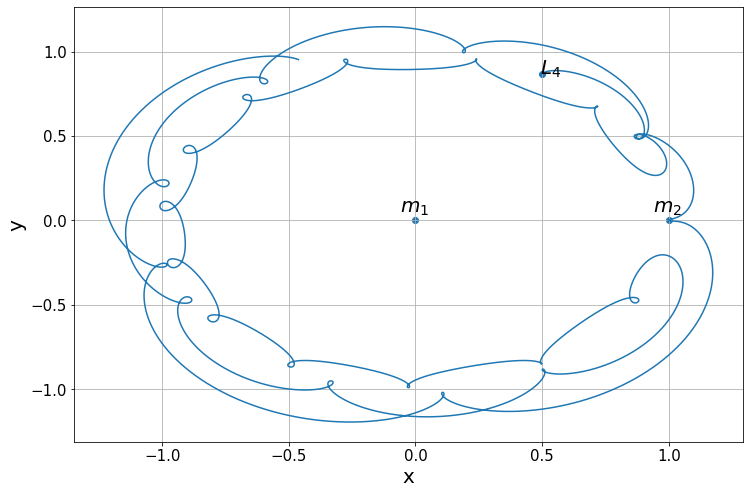

In [182]:
plt.figure(figsize = (12, 8))

plt.plot(r_tadpole[:, 0, 0], r_tadpole[:, 0, 1])

plt.scatter([1/2-mu, -mu, 1-mu], [np.sqrt(3)/2, 0., 0.])
plt.text(1/2-mu-6e-3, np.sqrt(3)/2 + 1e-5, s = r'$L_4$', fontsize = 20)

plt.text(-mu-6e-2, 0.05, s = r'$m_1$', fontsize = 20)
plt.text(1-mu-6e-2, 0.05, s = r'$m_2$', fontsize = 20)


plt.xlabel('x', fontsize = 20)
plt.ylabel('y', fontsize = 20)

plt.tick_params(labelsize = 15)

plt.grid(visible = True)

#plt.savefig('horseshoe.pdf', format = 'pdf')
